# Ovarian cancer data analysis
Train steamboat model on HGSC data.

In [5]:
import os
import scanpy as sc
import squidpy as sq
import numpy as np
import scipy as sp
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import json

In [6]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['font.family'] = 'arial'

pltkw = dict(bbox_inches='tight', transparent=True)

In [7]:
import sys
sys.path.append("..")
import steamboat as sf
import steamboat.tools
import torch
device = 'cuda'

In [8]:
import importlib
importlib.reload(steamboat.tools)

<module 'steamboat.tools' from 'g:\\Projects\\Steamboat\\revised\\..\\steamboat\\tools.py'>

In [9]:
# https://www.nature.com/articles/s41590-024-01943-5

## Load data

In [10]:
regenerate = False

h5ad_file = "../../../data/HGSC/ST_Discovery_so.h5ad"
if (not os.path.exists(h5ad_file)) or regenerate:
    adata = sc.read_mtx("G:/data/HGSC/Csv/ST_Discovery_so_counts.mtx").T
    metadata = pd.read_csv("G:/data/HGSC/Csv/ST_Discovery_so_metadata.csv", index_col=0)
    features = pd.read_csv("G:/data/HGSC/Csv/ST_Discovery_so_features.txt", index_col=0, header=None)
    features.index = features.index.str.strip() # remove trailing white space in gene names
    features.index.name = 'gene_symbol'
    adata.obs = metadata
    adata.var = features
    adata.obsm['spatial'] = adata.obs[['x', 'y']].to_numpy()
    adata.write_h5ad("G:/data/HGSC/h5ad/ST_Discovery_so.h5ad")
else:
    adata = sc.read_h5ad(h5ad_file)

In [11]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,samples,patients,sites_binary,cell.types,cell.subtypes,x,y
SMI_T10_F001_c1017,SMI,848,357,SMI_T10_F001,HGSC1,Adnexa,Malignant,Malignant,1493.3500,3151.233
SMI_T10_F001_c102,SMI,731,319,SMI_T10_F001,HGSC1,Adnexa,Malignant,Malignant,2623.2000,3607.450
SMI_T10_F001_c1062,SMI,236,155,SMI_T10_F001,HGSC1,Adnexa,Malignant,Malignant,850.5670,3143.833
SMI_T10_F001_c1064,SMI,609,300,SMI_T10_F001,HGSC1,Adnexa,Malignant,Malignant,3222.7300,3152.586
SMI_T10_F001_c1075,SMI,310,174,SMI_T10_F001,HGSC1,Adnexa,Malignant,Malignant,78.0125,3179.012
...,...,...,...,...,...,...,...,...,...,...
SMI_T14_F020_c5758,SMI,100,63,SMI_T14_F020,HGSC89,Omentum,TNK.cell,CD4.T.cell.DN,5170.4400,431.900
SMI_T14_F020_c734,SMI,141,88,SMI_T14_F020,HGSC89,Omentum,Fibroblast,Fibroblast,768.7000,3188.400
SMI_T14_F020_c875,SMI,78,60,SMI_T14_F020,HGSC89,Omentum,Malignant,Malignant,42.5833,3070.350
SMI_T14_F020_c3288,SMI,104,58,SMI_T14_F020,HGSC89,Omentum,Fibroblast,Fibroblast,48.9889,1751.740


In [12]:
TNK_info = adata.obs[adata.obs['cell.types'] == 'Monocyte']
TNK_info['cell.subtypes'].value_counts()

cell.subtypes
Monocyte            35182
B.cell                  0
B.cell_LC               0
Treg                    0
T.cell.DP_LC            0
T.cell.DP               0
T.B.cell_LC             0
T.B.cell                0
NK.cell_LC              0
NK.cell                 0
Monocyte_LC             0
Mast.cell_LC            0
Mast.cell               0
Malignant_LC            0
Malignant               0
Fibroblast_LC           0
Fibroblast              0
Endothelial_LC          0
Endothelial             0
CD8.T.cell_LC           0
CD8.T.cell              0
CD4.T.cell_LC           0
CD4.T.cell.DN_LC        0
CD4.T.cell.DN           0
CD4.T.cell              0
Treg_LC                 0
Name: count, dtype: int64

In [13]:
## Metadata and gene sets

sample_metadata = pd.read_excel("../../../data/HGSC/sample_metadata.xlsx", index_col=0, sheet_name='Table 2b', skiprows=1)
sample_metadata = sample_metadata[sample_metadata['dataset'] == 'Discovery']

celltype_signatures = pd.read_excel("G:/data/HGSC/sample_metadata.xlsx", sheet_name='Table 3a', skiprows=2)
mtil_signautures = pd.read_excel("G:/data/HGSC/sample_metadata.xlsx", sheet_name='Table 6a', skiprows=2)
desmoplasia_signautures = pd.read_excel("G:/data/HGSC/sample_metadata.xlsx", sheet_name='Table 5a', skiprows=2)

def purge_gene_sets(df, prefix=''):
    res = {}
    for i in df.columns:
        res[prefix + i] = df[i].dropna().tolist()
    return res
celltype_signatures = pd.read_excel("G:/data/HGSC/sample_metadata.xlsx", index_col=0, sheet_name='Table 3b', skiprows=2).iloc[:, :-3]
genesets = (purge_gene_sets(celltype_signatures, 'sig_') | 
            purge_gene_sets(mtil_signautures, 'mtil_') | 
            purge_gene_sets(mtil_signautures, 'mtil_'))
genesets.keys()
del genesets['sig_Mast.cell']

sample_metadata

,dataset,platform,n_cells,median_tpc,mean_tpc,TMA,patients,sites_binary,age,stage,...,fu_time2,outcome,pfs,BRCA1_Somatic,BRCA2_Somatic,TP53_Somatic,BRCA1_Germline,BRCA2_Germline,TP53_Germline,tmb
profile,,,,,,,,,,,,,,,,,,,,,
SMI_T10_F001,Discovery,SMI,5660,205.0,238.675618,TMA 10,HGSC1,Adnexa,58.0,III,...,775.0,Alive,775.0,WT,P,P,US,US,US,6.80
SMI_T10_F002,Discovery,SMI,8821,364.0,393.318671,TMA 10,HGSC7,Adnexa,58.0,III,...,1013.0,Alive,1013.0,P,WT,LP,US,US,US,0.53
SMI_T10_F003,Discovery,SMI,2881,300.0,445.154460,TMA 10,HGSC8,Adnexa,65.0,IV,...,781.0,Alive,200.0,WT,WT,P,US,US,US,3.16
SMI_T10_F004,Discovery,SMI,3145,286.0,376.895390,TMA 10,HGSC13,Omentum,67.0,III,...,840.0,Dead (disease),161.0,WT,WT,P,US,US,US,2.63
SMI_T10_F005,Discovery,SMI,2187,165.0,267.202561,TMA 10,HGSC15,Adnexa,33.0,IV,...,845.0,Alive,845.0,WT,WT,P,P,US,US,2.63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SMI_T14_F016,Discovery,SMI,2744,209.0,288.211735,TMA 14,HGSC61,Omentum,70.0,III,...,1955.0,Alive,1955.0,WT,WT,P,US,US,US,1.10
SMI_T14_F017,Discovery,SMI,3376,276.0,368.816647,TMA 14,HGSC63,Omentum,71.0,III,...,407.0,D/c to hospice (likely dead of disease),297.0,WT,WT,P,US,US,US,0.50
SMI_T14_F018,Discovery,SMI,9961,189.0,210.500452,TMA 14,HGSC89,Adnexa,53.0,III,...,1729.0,Dead (disease),412.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


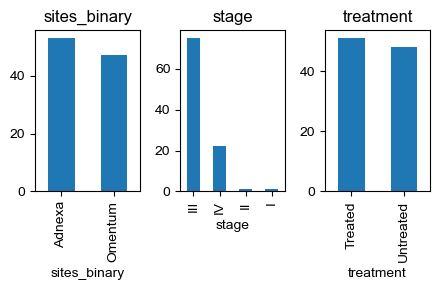

In [14]:
## Find untreated, adnexa samples

columns_of_interest = ['sites_binary', 'stage', 'treatment']
fig, axes = plt.subplots(1, len(columns_of_interest), figsize=(len(columns_of_interest) * 1.5, 3))
for i, column in enumerate(columns_of_interest):
    sample_metadata[column].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(column)
plt.tight_layout()

mask = (sample_metadata['sites_binary'] == 'Adnexa') & (sample_metadata['treatment'] == 'Untreated')
samples_of_interest = sample_metadata.index[mask].tolist()

all_adata = adata[adata.obs['samples'].isin(samples_of_interest)].copy()
all_adata.obs['cell.types.nolc'] = all_adata.obs['cell.types'].str.replace('_LC', '')

In [15]:
# selected_samples = np.random.choice(all_adata.obs['samples'].unique(), size=10, replace=False)
# all_adata = all_adata[all_adata.obs['samples'].isin(selected_samples)].copy()

### Process data to create torch dataset

In [16]:
# Separate individual slides
adatas = []
for i in all_adata.obs['samples'].unique():
    temp = all_adata[all_adata.obs['samples'] == i].copy()
    if temp.shape[0] < 100:
        continue
    adatas.append(temp)
    adatas[-1].obs['global'] = 0

# normalize and log transformation
adatas = sf.prep_adatas(adatas, norm=True, log1p=True, scale=False, renorm=False)

# create torch dataset
dataset = sf.make_dataset(adatas, sparse_graph=True, regional_obs=['global'])

  0%|          | 0/27 [00:00<?, ?it/s]

Using ['global'] as regional annotations.


  0%|          | 0/27 [00:00<?, ?it/s]

In [ ]:
print(*adata.obs['cell.types'].unique())

Malignant Fibroblast Monocyte TNK.cell Malignant_LC B.cell Endothelial_LC Endothelial Fibroblast_LC TNK.cell_LC B.cell_LC Monocyte_LC Mast.cell_LC Mast.cell


In [17]:
immune_types = ['TNK.cell', 'B.cell', 'Monocyte', 'Mast.cell']
fibroblast_types = ['Fibroblast']



In [18]:
cuda_dataset = None

load_data_into_gpu = True # if you run into OOM on GPU, set this to False
if device == 'cuda' and load_data_into_gpu:
    cuda_dataset = dataset.to('cuda')

In [19]:
n_heads = 25

sf.set_random_seed(0)
model = sf.Steamboat(adata.var_names.tolist(), n_heads=n_heads, n_scales=3)
model = model.to(device)

use_dataset = cuda_dataset
if use_dataset is None:
    use_dataset = dataset

model.load_state_dict(torch.load('../examples/saved_models/hgsc.pth', weights_only=True), strict=False)

# model.fit(cuda_dataset, entry_masking_rate=0.1, feature_masking_rate=0.1,
#           max_epoch=10000, 
#           loss_fun=torch.nn.MSELoss(reduction='sum'),
#           opt=torch.optim.Adam, opt_args=dict(lr=0.1), stop_eps=1e-3, report_per=200, stop_tol=200, device=device)

c:\Users\lshh\miniconda3\envs\py311_torch211_cuda121\Lib\site-packages\torch\_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


<All keys matched successfully>

In [20]:
sf.tools.calc_obs(adatas, dataset, model, get_recon=True)

  0%|          | 0/27 [00:00<?, ?it/s]

In [21]:
# find TNK spots that do NOT neighbor any Monocyte (per-sample)
tnk_no_monocyte_by_sample = {}

for ad in adatas:
    sample = ad.obs['samples'].unique()[0]

    # find a spatial connectivity matrix (same logic as earlier)
    conn = None
    if 'spatial_connectivities' in ad.obsp:
        conn = ad.obsp['spatial_connectivities']
    elif 'connectivities' in ad.obsp:
        conn = ad.obsp['connectivities']
    elif 'spatial_neighbors' in ad.uns and 'connectivities' in ad.uns['spatial_neighbors']:
        conn = ad.uns['spatial_neighbors']['connectivities']

    if conn is None:
        print(f"{sample}: no spatial connectivity matrix found, skipping")
        continue

    # ensure CSR
    if sp.sparse.issparse(conn):
        conn = conn.tocsr()
    else:
        conn = sp.sparse.csr_matrix(conn)

    # boolean masks
    monocyte_mask = ad.obs['cell.subtypes'].astype(str).isin(['Monocyte']).values
    tnk_mask = ad.obs['cell.types'].astype(str).isin(['TNK.cell']).values

    if monocyte_mask.sum() == 0:
        # no monocytes in this sample -> all fibroblasts have no monocyte neighbors
        fibro_idx = np.flatnonzero(tnk_mask)
    else:
        # number of edges from each cell to monocytes
        to_monocyte_counts = np.asarray(conn[:, monocyte_mask].sum(axis=1)).squeeze()
        # TNK cells with zero monocyte neighbors
        tnk_no_mon_mask = tnk_mask & (to_monocyte_counts == 0)
        tnk_idx = np.flatnonzero(tnk_no_mon_mask)

    # record in AnnData and dict
    # ad.obs['tnk_no_monocyte_neighbor'] = False
    # if monocyte_mask.sum() > 0:
    #     ad.obs.loc[ad.obs.index[tnk_idx], 'tnk_no_monocyte_neighbor'] = True
    # else:
    ad.obs['tnk_no_monocyte_neighbor'] = tnk_mask

    # tnk_no_monocyte_by_sample[sample] = tnk_idx
    print(f"{sample}: {ad.obs['tnk_no_monocyte_neighbor'].sum()} TNK cell(s) without Monocyte neighbor (n_cells={ad.shape[0]})")

# tnk_no_monocyte_by_sample now maps sample -> numpy array of row indices for TNK cells without monocyte neighbors

SMI_T10_F001: 253 TNK cell(s) without Monocyte neighbor (n_cells=5660)
SMI_T10_F002: 345 TNK cell(s) without Monocyte neighbor (n_cells=8821)
SMI_T10_F006: 141 TNK cell(s) without Monocyte neighbor (n_cells=5295)
SMI_T10_F014: 24 TNK cell(s) without Monocyte neighbor (n_cells=5944)
SMI_T11_F001: 3 TNK cell(s) without Monocyte neighbor (n_cells=2212)
SMI_T11_F002: 316 TNK cell(s) without Monocyte neighbor (n_cells=3267)
SMI_T11_F004: 107 TNK cell(s) without Monocyte neighbor (n_cells=8088)
SMI_T11_F008: 86 TNK cell(s) without Monocyte neighbor (n_cells=2967)
SMI_T11_F009: 42 TNK cell(s) without Monocyte neighbor (n_cells=4311)
SMI_T11_F011: 0 TNK cell(s) without Monocyte neighbor (n_cells=3876)
SMI_T11_F020: 35 TNK cell(s) without Monocyte neighbor (n_cells=6266)
SMI_T12_F005: 190 TNK cell(s) without Monocyte neighbor (n_cells=8201)
SMI_T12_F007: 13 TNK cell(s) without Monocyte neighbor (n_cells=7039)
SMI_T12_F009: 239 TNK cell(s) without Monocyte neighbor (n_cells=9875)
SMI_T12_F013: 1

In [22]:
# Label neighboring cells in obs
for ad in adatas:
    # Initialize the column with False
    ad.obs['neighbor_of_tnk_no_monocyte'] = False

    # Get the spatial connectivity matrix
    conn = None
    if 'spatial_connectivities' in ad.obsp:
        conn = ad.obsp['spatial_connectivities']
    elif 'connectivities' in ad.obsp:
        conn = ad.obsp['connectivities']
    elif 'spatial_neighbors' in ad.uns and 'connectivities' in ad.uns['spatial_neighbors']:
        conn = ad.uns['spatial_neighbors']['connectivities']

    if conn is None:
        print(f"{ad.obs['samples'].unique()[0]}: no spatial connectivity matrix found, skipping")
        continue

    # Ensure CSR format
    if sp.sparse.issparse(conn):
        conn = conn.tocsr()
    else:
        conn = sp.sparse.csr_matrix(conn)

    # Find indices of cells with tnk_no_monocyte_neighbor = True
    tnk_no_monocyte_mask = ad.obs['tnk_no_monocyte_neighbor'].values
    tnk_no_monocyte_indices = np.flatnonzero(tnk_no_monocyte_mask)

    # Find neighbors of these cells
    neighbor_indices = conn[tnk_no_monocyte_indices].indices

    # Update the column to True for neighboring cells
    ad.obs.iloc[neighbor_indices, ad.obs.columns.get_loc('neighbor_of_tnk_no_monocyte')] = True

    print(f"{ad.obs['samples'].unique()[0]}: Labeled {ad.obs['neighbor_of_tnk_no_monocyte'].sum()} neighboring cells")


SMI_T10_F001: Labeled 1398 neighboring cells
SMI_T10_F002: Labeled 2173 neighboring cells
SMI_T10_F006: Labeled 841 neighboring cells
SMI_T10_F014: Labeled 179 neighboring cells
SMI_T11_F001: Labeled 22 neighboring cells
SMI_T11_F002: Labeled 1512 neighboring cells
SMI_T11_F004: Labeled 756 neighboring cells
SMI_T11_F008: Labeled 439 neighboring cells
SMI_T11_F009: Labeled 258 neighboring cells
SMI_T11_F011: Labeled 0 neighboring cells
SMI_T11_F020: Labeled 274 neighboring cells
SMI_T12_F005: Labeled 1223 neighboring cells
SMI_T12_F007: Labeled 94 neighboring cells
SMI_T12_F009: Labeled 1096 neighboring cells
SMI_T12_F013: Labeled 142 neighboring cells
SMI_T12_F015: Labeled 2782 neighboring cells
SMI_T12_F018: Labeled 113 neighboring cells
SMI_T13_F005: Labeled 8 neighboring cells
SMI_T13_F009: Labeled 370 neighboring cells
SMI_T13_F011: Labeled 1208 neighboring cells
SMI_T13_F018: Labeled 1652 neighboring cells
SMI_T13_F019: Labeled 1283 neighboring cells
SMI_T14_F002: Labeled 748 nei

In [23]:
perturbed_adatas = [adata.copy() for adata in adatas]

np.random.seed(0)

# keep original cell types
for ad in perturbed_adatas:
    if 'cell.types_orig' not in ad.obs.columns:
        ad.obs['cell.types_orig'] = ad.obs['cell.types'].astype(object)

for ad in perturbed_adatas:
    ct = ad.obs['cell.types'].astype(str)
    # replace_mask = ct.isin(old_celltypes)
    # find all neighbors of immune cells that are not immune cells
    replace_mask = ad.obs['neighbor_of_tnk_no_monocyte']
    replace_idx = np.flatnonzero(replace_mask.values)
    n_replace = len(replace_idx)
    # print(n_replace)
    if n_replace <= 0:
        continue

    replace_idx = np.random.choice(replace_idx, size=n_replace, replace=False)

    # try sampling immune cells from the same slide
    immune_mask = ad.obs['cell.types'].astype(str).isin(['Monocyte'])
    immune_idx = np.flatnonzero(immune_mask.values)

    if len(immune_idx) > 0:
        sampled_from_idx = np.random.choice(immune_idx, size=n_replace, replace=True)
        sampled_X = ad.X[sampled_from_idx].toarray() if sp.sparse.issparse(ad.X) else np.array(ad.X[sampled_from_idx]).copy()
        sampled_types = ad.obs['cell.types'].iloc[sampled_from_idx].tolist()
    else:
        print(f"No immune cells found in sample {ad.obs['samples'].unique()[0]}. Ignore.")
        continue

    # ensure dense array for assignment (assigning back to ad.X as dense)
    X_dense = ad.X.toarray() if sp.sparse.issparse(ad.X) else np.array(ad.X)
    X_dense[replace_idx] = sampled_X
    ad.X = X_dense

    # update obs: set replaced cells to sampled immune types and mark them
    ad.obs.loc[ad.obs.index[replace_idx], 'cell.types'] = sampled_types
    ad.obs['replaced'] = False
    ad.obs.loc[ad.obs.index[replace_idx], 'replaced'] = True

    print(n_replace)

# finished

perturbed_dataset = sf.make_dataset(perturbed_adatas, sparse_graph=True, regional_obs=['global'])
sf.tools.calc_obs(perturbed_adatas, perturbed_dataset, model, get_recon=True)

1398
2173
841
179
22
1512
756
439
258
274
1223
94
1096
142
2782
113
8
370
1208
1652
1283
748
32
211
512
24
Using ['global'] as regional annotations.


  0%|          | 0/27 [00:00<?, ?it/s]

  0%|          | 0/27 [00:00<?, ?it/s]

In [24]:
# Score each sample (AnnData in `adatas`) for the inflammatory gene set restricted to immune cells.
def compute_geneset_scores(adatas, obs, measure_subset, geneset, obsm=None):
    if not isinstance(measure_subset, list):
        measure_subset = [measure_subset]
    results = []
    for ad in adatas:
        sample = ad.obs['samples'].unique()[0]
        measure_mask = ad.obs[obs].isin(measure_subset)
        n_measure = int(measure_mask.sum())
        pct_measure = n_measure / ad.shape[0] * 100.0
        # intersect genes with var_names
        genes_in_data = [g for g in geneset if g in ad.var_names]
        if len(genes_in_data) == 0 or n_measure == 0:
            results.append({
                'sample': sample,
                'n_measure_cells': n_measure,
                'n_genes_used': len(genes_in_data),
                'mean_measure_score': np.nan,
                'median_measure_score': np.nan,
                'std_measure_score': np.nan,
                'mean_notmeasure_score': np.nan,
                'score_diff_measure_minus_notmeasure': np.nan,
                'ttest_pval': np.nan
            })
            continue

        # compute per-spot gene set score (adds ad.obs['inflammatory_score'])
        # sc.tl.score_genes(ad, gene_list=genes_in_data, score_name='inflammatory_score', use_raw=False)
        
        # scores = ad.obs['inflammatory_score']
        if obsm is None:
            scores = pd.Series(np.array(ad[:, genes_in_data].X.mean(axis=1)).squeeze(), index=ad.obs.index)  # mean expression of the gene set
        else:
            scores = pd.Series(np.array(ad.obsm['X_recon'][:, ad.var_names.isin(genes_in_data)].mean(axis=1)).squeeze(), index=ad.obs.index)  # mean expression of the gene set
        
        measure_scores = scores[measure_mask]
        notmeasure_scores = scores[~measure_mask]

        mean_measure = float(measure_scores.mean())
        median_measure = float(measure_scores.median())
        std_measure = float(measure_scores.std())
        mean_notmeasure = float(notmeasure_scores.mean()) if len(notmeasure_scores) > 0 else np.nan
        diff = mean_measure - mean_notmeasure if not np.isnan(mean_notmeasure) else np.nan

        # t-test between measure and not-measure (if non-empty)
        if len(notmeasure_scores) > 0:
            tstat, pval = sp.stats.ttest_ind(measure_scores, notmeasure_scores, equal_var=False, nan_policy='omit')
        else:
            pval = np.nan

        results.append({
            'sample': sample,
            'n_measure_cells': n_measure,
            'pct_measure': pct_measure,
            'n_genes_used': len(genes_in_data),
            'mean_measure_score': mean_measure,
            'median_measure_score': median_measure,
            'std_measure_score': std_measure,
            'mean_notmeasure_score': mean_notmeasure,
            'score_diff_measure_minus_notmeasure': diff,
            'ttest_pval': pval
        })

    # assemble results table
    geneset_scores_by_sample = pd.DataFrame(results).set_index('sample').sort_values('mean_measure_score', ascending=False)
    return geneset_scores_by_sample

In [25]:
genesets = {}

path = "G:/Projects/Steamboat/revised/selected_genesets"

for filename in os.listdir(path):
    with open(os.path.join(path, filename), 'r', encoding='utf-8') as f:
        json_data = json.load(f)
        for k in json_data:
            genesets[k] = json_data[k]['geneSymbols']

print(*genesets.keys(), sep='\n')

HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION
HALLMARK_INFLAMMATORY_RESPONSE
HALLMARK_TGF_BETA_SIGNALING
KEGG_CYTOKINE_CYTOKINE_RECEPTOR_INTERACTION
REACTOME_CYTOKINE_SIGNALING_IN_IMMUNE_SYSTEM


In [26]:

relevant_genesets = ['HALLMARK_INFLAMMATORY_RESPONSE', 'REACTOME_CYTOKINE_SIGNALING_IN_IMMUNE_SYSTEM']
geneset_changes = {}

for geneset_name in relevant_genesets:
   scores_by_sample_recon = compute_geneset_scores(adatas, 'tnk_no_monocyte_neighbor', True, 
                                                               genesets[geneset_name], 
                                                                     obsm='X_recon')
   scores_by_sample_recon.columns = [col + '_recon' for col in scores_by_sample_recon.columns]
   scores_by_sample_perturb = compute_geneset_scores(perturbed_adatas, 'tnk_no_monocyte_neighbor', True, 
                                                                  genesets[geneset_name], 
                                                                     obsm='X_recon')
   scores_by_sample_perturb.columns = [col + '_perturb' for col in scores_by_sample_perturb.columns]

   merged_scores = pd.merge(scores_by_sample_recon, scores_by_sample_perturb, 
                                       left_index=True, right_index=True)
   
   up_val = (merged_scores['mean_measure_score_perturb'] - merged_scores['mean_measure_score_recon'])
   up_pct = up_val / merged_scores['mean_measure_score_recon'] * 100.0
   geneset_changes[geneset_name] = up_pct
# 

c:\Users\lshh\miniconda3\envs\py311_torch211_cuda121\Lib\site-packages\scipy\stats\_stats_py.py:1103: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
c:\Users\lshh\miniconda3\envs\py311_torch211_cuda121\Lib\site-packages\scipy\stats\_stats_py.py:1103: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
c:\Users\lshh\miniconda3\envs\py311_torch211_cuda121\Lib\site-packages\scipy\stats\_stats_py.py:1103: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
c:\Users\lshh\miniconda3\envs\py311_torch211_cuda121\Lib\site-packages\scipy\stats\_stats_py.py:1103: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
c:\Users\lshh\miniconda3\envs\py311_torch211_cuda121\Lib\site-packages\scipy\stats\_stats_py

C:\Users\lshh\AppData\Local\Temp\ipykernel_115736\1330587154.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Inflammatory\nresponse\n(Hallmark)",


HALLMARK_INFLAMMATORY_RESPONSE REACTOME_CYTOKINE_SIGNALING_IN_IMMUNE_SYSTEM


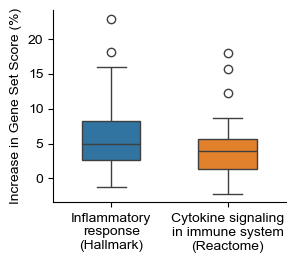

In [27]:
fig, ax = plt.subplots(figsize=(3, 2.5))
sns.boxplot(geneset_changes, ax=ax, width=0.5)

def aes_text(s):
    return s.replace('_', '\n')

# ax.set_xticklabels([i.get_text().replace('_', '\n') for i in ax.get_xticklabels()])
print(*[i.get_text() for i in ax.get_xticklabels()])
ax.set_xticklabels(["Inflammatory\nresponse\n(Hallmark)",
                    "Cytokine signaling\nin immune system\n(Reactome)"])

ax.set_ylabel('Increase in Gene Set Score (%)')
for pos in ['right', 'top']:
    ax.spines[pos].set_visible(False)



In [28]:
import pickle as pkl
with open('saved_figure_data/hgsc_inflammation.pkl', 'wb') as f:
    pkl.dump(geneset_changes, f)

In [29]:
sp.stats.ttest_1samp(geneset_changes['HALLMARK_INFLAMMATORY_RESPONSE'].dropna(), 0)

TtestResult(statistic=5.782820426485225, pvalue=4.9978946749382635e-06, df=25)

In [30]:
sp.stats.ttest_1samp(geneset_changes['REACTOME_CYTOKINE_SIGNALING_IN_IMMUNE_SYSTEM'].dropna(), 0)

TtestResult(statistic=4.870099516481239, pvalue=5.217210340039577e-05, df=25)